In [3]:
# ////////////////////////////////////////////
# SENTIMENT ANALYSIS ON TWITTER AIRLINE DATA
# Built by: Gayatri Padalia
# Dataset: Twitter US Airline Sentiment
# Model: Logistic Regression + TF-IDF
# ////////////////////////////////////////////
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')
# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix)
print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gayat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gayat\AppData\Roaming\nltk_data...


All libraries imported successfully!
Pandas version: 2.3.3
Numpy version: 1.26.4


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gayat\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
# ///////////////////////////////////////////////////////////
# /////////////////// Load & Explore Dataset ////////////////
#////////////////////////////////////////////////////////////
# Load dataset
df = pd.read_csv('Tweets.csv')
# Basic exploration
print("Dataset Shape:", df.shape)
print("\n Columns:", df.columns.tolist())
print("\n First 3 rows:")
display(df.head(3))
print("\n Sentiment Distribution:")
print(df['airline_sentiment'].value_counts())
print("\n Missing values:")
print(df.isnull().sum())

Dataset Shape: (14640, 15)

 Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

 First 3 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)



 Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

 Missing values:
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


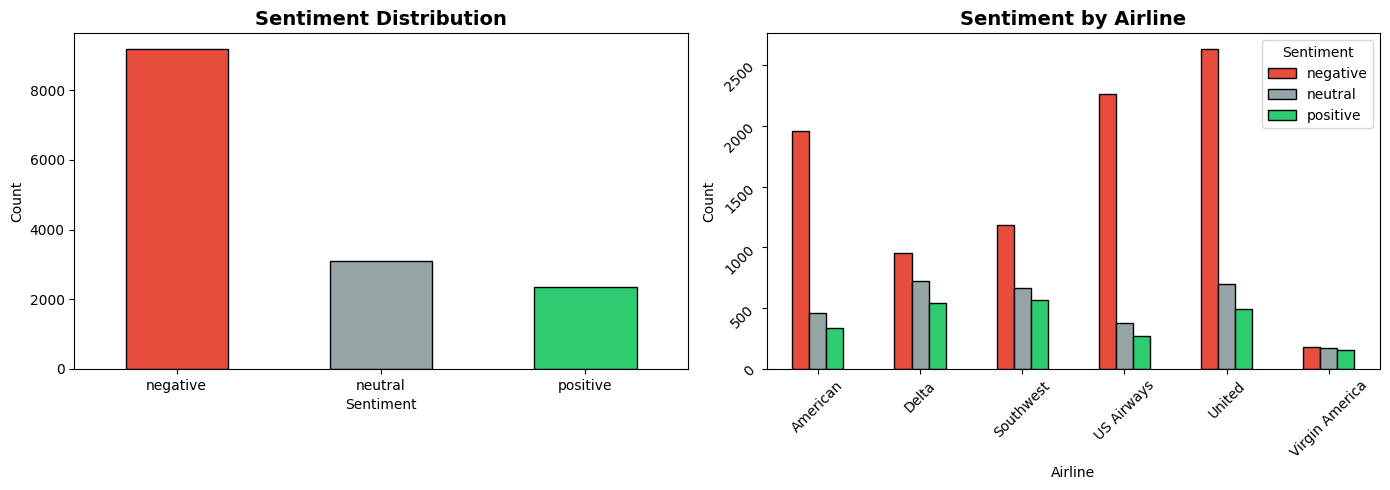

Charts saved as sentiment_distribution.png


In [5]:
# ///////////////////////////////////////////////////////////
# ///////////////////// Visualize the Data //////////////////
#////////////////////////////////////////////////////////////
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Chart 1 - Sentiment Count
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
df['airline_sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)
# Chart 2 - Sentiment by Airline
airline_sentiment = df.groupby(
    ['airline', 'airline_sentiment']).size().unstack()
airline_sentiment.plot(kind='bar', ax=axes[1], 
                       color=colors, edgecolor='black')
axes[1].set_title('Sentiment by Airline', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=45)
axes[1].legend(title='Sentiment')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as sentiment_distribution.png")

In [6]:
# ///////////////////////////////////////////////////////////
# ///////////////////// Clean the Text //////////////////////
#////////////////////////////////////////////////////////////
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# Keep negative words - important for sentiment!
negative_words = {'no', 'not', 'nor', 'neither', 
                  'never', 'none', "don't", "won't", 
                  "can't", "isn't", "aren't", "wasn't"}
stop_words = stop_words - negative_words
def clean_text(text):
    # Convert to string
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags symbol but keep word
    text = re.sub(r'#', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Remove stopwords and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)
print(" Cleaning tweets... please wait ")
df['clean_text'] = df['text'].apply(clean_text)
print(" Text cleaned successfully!")
# Show before/after
print("\n Before cleaning:")
print(df['text'].iloc[0])
print("\n✨ After cleaning:")
print(df['clean_text'].iloc[0])

 Cleaning tweets... please wait 
 Text cleaned successfully!

 Before cleaning:
@VirginAmerica What @dhepburn said.

✨ After cleaning:
said


In [7]:
# ///////////////////////////////////////////////////////////
# /////////////////// Prepare Data for ML ///////////////////
#////////////////////////////////////////////////////////////
# Select only what we need
df_model = df[['clean_text', 'airline_sentiment']].dropna()
# Encode labels
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_model['label'] = df_model['airline_sentiment'].map(label_map)
# TF-IDF Vectorization
# TF-IDF = how important a word is in a tweet vs all tweets
vectorizer = TfidfVectorizer(
    max_features=8000,      # top 8000 important words
    ngram_range=(1, 2),     # single words + word pairs
    min_df=2,               # word must appear at least twice
    sublinear_tf=True       # better scaling
)
X = vectorizer.fit_transform(df_model['clean_text'])
y = df_model['label']
print("Text converted to numbers!")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\n Label mapping: {label_map}")
print(f"Class distribution:\n{df_model['airline_sentiment'].value_counts()}")

Text converted to numbers!
Feature matrix shape: (14640, 8000)
Labels shape: (14640,)

 Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Class distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [ ]:
# ///////////////////////////////////////////////////////////
# /////////////////// Train the Model ///////////////////////
#////////////////////////////////////////////////////////////
# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
# Train Logistic Regression
print("\n Training model...")
model = LogisticRegression(
    max_iter=1000,
    C=1.0,                  # regularization
    class_weight='balanced', # handles imbalanced data
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained successfully!")

Training samples: 11712
Testing samples: 2928

 Training model...
✅ Model trained successfully!


In [9]:
# ///////////////////////////////////////////////////////////
# /////////////////// Evaluate the Model ////////////////////
#////////////////////////////////////////////////////////////
# Predictions
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f" Model Accuracy: {accuracy:.2%}")
# Detailed report
print("\n Classification Report:")
label_names = ['negative', 'neutral', 'positive']
print(classification_report(y_test, y_pred, 
                            target_names=label_names))

 Model Accuracy: 75.65%

 Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.79      0.84      1835
     neutral       0.53      0.71      0.61       620
    positive       0.69      0.70      0.69       473

    accuracy                           0.76      2928
   macro avg       0.70      0.73      0.71      2928
weighted avg       0.78      0.76      0.77      2928



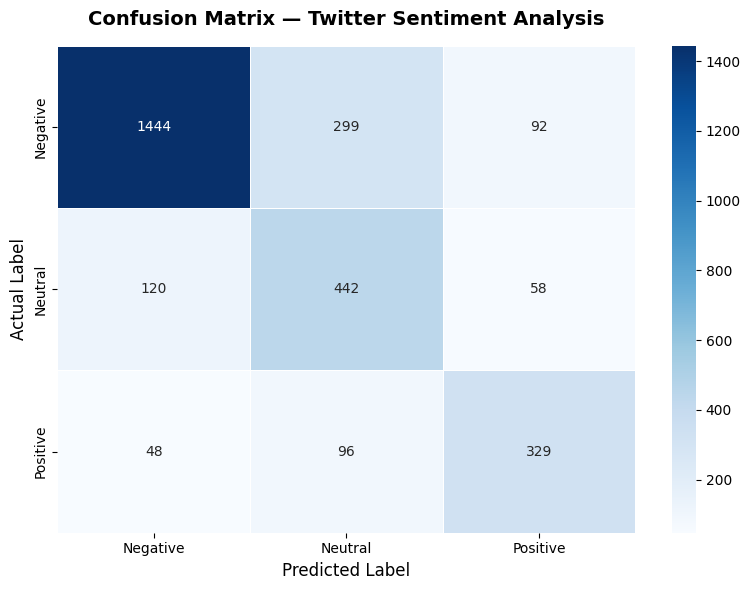

Confusion matrix saved!


In [10]:
# ///////////////////////////////////////////////////////////
# /////////////////// Confusion Matrix //////////////////////
#////////////////////////////////////////////////////////////
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            linewidths=0.5)
plt.title('Confusion Matrix — Twitter Sentiment Analysis', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

In [11]:
# ///////////////////////////////////////////////////////////
# /////////////////// Predict Any Tweet! ////////////////////
#////////////////////////////////////////////////////////////
def predict_sentiment(tweet):
    """
    Predicts sentiment of any tweet
    Input: raw tweet text (string)
    Output: sentiment label + confidence score
    """
    label_names = {0: '🔴 NEGATIVE', 
                   1: '⚪ NEUTRAL', 
                   2: '🟢 POSITIVE'}
    # Clean and predict
    cleaned = clean_text(tweet)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized).max()
    print(f"Tweet: {tweet}")
    print(f"Sentiment: {label_names[prediction]}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 50)
# Test with real examples!
predict_sentiment("United Airlines lost my bags and nobody helped me!")
predict_sentiment("Amazing flight, crew was super friendly and helpful!")
predict_sentiment("Flight was okay, landed on time nothing special")
predict_sentiment("Worst airline ever! Delayed 4 hours with no explanation!")
predict_sentiment("Thank you Delta for the smooth journey today!")

Tweet: United Airlines lost my bags and nobody helped me!
Sentiment: 🔴 NEGATIVE
Confidence: 65.74%
--------------------------------------------------
Tweet: Amazing flight, crew was super friendly and helpful!
Sentiment: 🟢 POSITIVE
Confidence: 95.72%
--------------------------------------------------
Tweet: Flight was okay, landed on time nothing special
Sentiment: 🔴 NEGATIVE
Confidence: 57.34%
--------------------------------------------------
Tweet: Worst airline ever! Delayed 4 hours with no explanation!
Sentiment: 🔴 NEGATIVE
Confidence: 98.79%
--------------------------------------------------
Tweet: Thank you Delta for the smooth journey today!
Sentiment: 🟢 POSITIVE
Confidence: 81.77%
--------------------------------------------------
